# Chapter 16: Thought as Search

Generating another answer can improve the chance that some answer is correct. It does not ensure that the controller can recognize it. A selector that shares the same misconception can confidently choose the wrong candidate while total compute rises.

This notebook separates coverage, selection, cost, and time. You provide several candidate allocations, a correctness construction, and a conditional selector accuracy. The method removes allocations that miss the budget or deadline, then chooses the feasible one with the greatest declared selected success. The changed case replaces independent candidate errors with a shared failure condition. Marginal correctness stays fixed while the benefit of additional sampling changes.

**Outcome:** Separate candidate coverage from actual selector success and choose a feasible allocation.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

Under independent equal candidate correctness p, the probability that at least one of n candidates is correct is C_n=1-(1-p)^n. Under one shared good/bad condition, C_n=p for every positive n. Equal marginals do not distinguish those joint laws.

For n>1 with independent errors, this implementation defines selected success as q C_n, where q is the probability that the selector chooses a correct candidate conditional on one existing. Under the shared condition a bank that holds a correct candidate holds only correct candidates, so any choice from it is correct and selected success equals C_n=p whatever q is. When n=1 the selector is bypassed, so success is p. This convention matters: with independent errors, paying an unreliable selector can make two samples worse than one.

Expense is n c_sample+c_selector and serial latency is n t_sample+t_selector for multiple candidates. Single-candidate allocation omits selector overhead. Feasibility requires both quantities to lie within declared limits. The selected allocation maximizes success, breaking ties toward lower expense. A candidate count with high oracle coverage is not necessarily feasible or operationally best.

## Apply this to an agent

Generating more candidate actions helps only if the controller can select a correct one within its budget and deadline. Compare coverage with actual selection, then replace independent errors with a shared failure. More attempts cannot remove a failure common to every attempt.

## A calculation you can run

Provide candidate counts and all probability, cost, latency, deadline, and dependence inputs. Numeric validation rejects negative resource values, invalid probabilities, and unsupported counts. For each allocation the function calculates coverage, selected success, expense, latency, and feasibility, preserving every row for inspection.

The two figures compare oracle coverage and selector completion by sample count. Their gap is the selector boundary, not an error bar. The selected allocation may skip the visually highest point if it violates a resource constraint. In the changed case keep every scalar fixed and enable shared_error. Predict which row now wins and explain why sampling no longer improves coverage. Export dependence and selector assumptions with the result.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 16
inputs = {'candidate_success': 0.4,
 'selector_accuracy': 0.9,
 'sample_cost': 1,
 'sample_latency': 1,
 'selector_cost': 1,
 'selector_latency': 1,
 'deadline': 6,
 'budget': 6,
 'shared_error': False,
 'sample_counts': [1, 2, 3, 5]}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 16: sample-allocation
How many candidates should the controller generate under cost and deadline constraints?
Evidence: constructed teaching example

Calculated quantities:
{
  "selected_allocation": {
    "samples": 5,
    "coverage": 0.92224,
    "selected_success": 0.830016,
    "cost": 6.0,
    "latency": 6.0,
    "feasible": true
  },
  "allocations": [
    {
      "samples": 1,
      "coverage": 0.4,
      "selected_success": 0.4,
      "cost": 1.0,
      "latency": 1.0,
      "feasible": true
    },
    {
      "samples": 2,
      "coverage": 0.64,
      "selected_success": 0.576,
      "cost": 3.0,
      "latency": 3.0,
      "feasible": true
    },
    {
      "samples": 3,
      "coverage": 0.784,
      "selected_success": 0.7056,
      "cost": 4.0,
      "latency": 4.0,
      "feasible": true
    },
    {
      "samples": 5,
      "coverage": 0.92224,
      "selected_success": 0.830016,
      "cost": 6.0,
      "latency": 6.0,
      "feasible": true
    }
  ],
  "sha

Default coverage at n=5 is 1-0.6^5=0.92224. Selected success is 0.9 times that value, or 0.830016. Cost and serial latency are both 6, so this allocation exactly fits the limits and wins among the listed options.

Under shared error, every multiple-candidate row has coverage 0.4 and selected success 0.4: a bank with a correct candidate holds only correct candidates, so the selector's 0.9 accuracy makes no difference. The single candidate bypasses selection and also delivers 0.4, with lower expense. It therefore wins the tie. More samples now add cost without improving justified completion, even though each candidate has the same marginal correctness as before.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


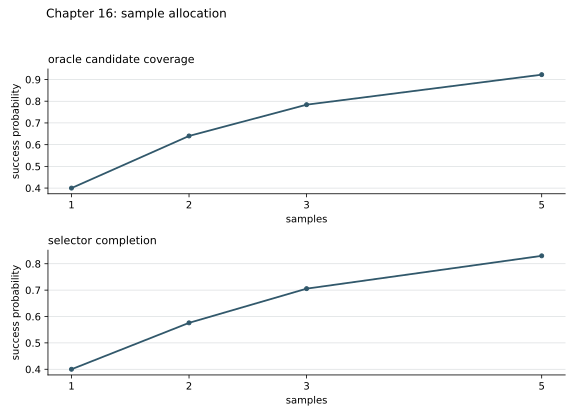

In [3]:
display(SVG(figure_svg(report)))

**Figure 16.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

The formula q C_n for independent errors is a declared selector model. Real selector accuracy can depend on candidate count, task difficulty, disagreement, or the distribution of wrong answers. A constant q should not be adopted merely because it makes the curve easy to draw. Measure it on held-out candidate sets or state its uncertainty.

Independence is another strong assumption. Repeated samples from one shared flawed context can agree for the wrong reason. The changed construction is deliberately extreme, showing why marginal correctness alone cannot justify the usual saturation curve.

Resource models also need care. Parallel generation changes latency, and a deadline can alter selector behavior. This notebook uses serial time and fixed overhead. If no row is feasible, the selected allocation is unavailable; it does not invent a smaller budget or recommend exceeding a hard limit.

Chapter 16: sample-allocation
How many candidates should the controller generate under cost and deadline constraints?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "selected_allocation": {
    "samples": 1,
    "coverage": 0.4,
    "selected_success": 0.4,
    "cost": 1.0,
    "latency": 1.0,
    "feasible": true
  },
  "allocations": [
    {
      "samples": 1,
      "coverage": 0.4,
      "selected_success": 0.4,
      "cost": 1.0,
      "latency": 1.0,
      "feasible": true
    },
    {
      "samples": 2,
      "coverage": 0.4,
      "selected_success": 0.4,
      "cost": 3.0,
      "latency": 3.0,
      "feasible": true
    },
    {
      "samples": 3,
      "coverage": 0.4,
      "selected_success": 0.4,
      "cost": 4.0,
      "latency": 4.0,
      "feasible": true
    },
    {
      "samples": 5,
      "coverage": 0.4,
      "selected_success": 0.4,
      "cost": 6.0,
      "latency": 6.0,
      "feasible": true
    }
  ],
  "shared_error": true

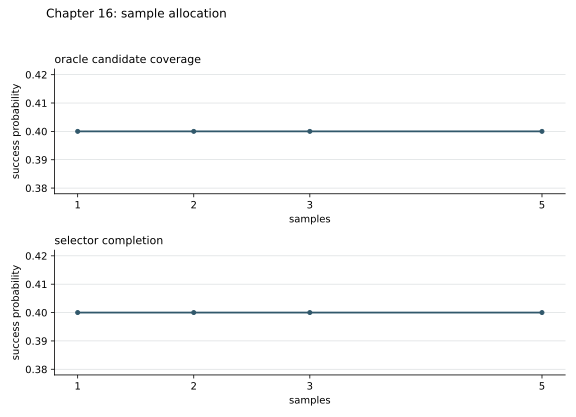

In [4]:
changed_inputs = {'candidate_success': 0.4,
 'selector_accuracy': 0.9,
 'sample_cost': 1,
 'sample_latency': 1,
 'selector_cost': 1,
 'selector_latency': 1,
 'deadline': 6,
 'budget': 6,
 'shared_error': True,
 'sample_counts': [1, 2, 3, 5]}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 16.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer case gives single-candidate success 0.7. Multiple candidates face selector accuracy 0.5 and overhead that makes them miss the three-unit deadline or six-unit budget. The feasible recommendation is one candidate, even though an oracle would see broader coverage in a larger bank.

For local allocation data, distinguish candidate success evidence from selector evidence. Record whether failures are independent, shared, or simply unknown. Unknown dependence calls for a measurement design or sensitivity constructions, not an automatic independence assumption. Use run-level evaluation after executing the chosen allocation to test actual authorized confirmed completion.

In [5]:
transfer_inputs = {'candidate_success': 0.7,
 'selector_accuracy': 0.5,
 'sample_cost': 2,
 'sample_latency': 1,
 'selector_cost': 3,
 'selector_latency': 2,
 'deadline': 3,
 'budget': 6,
 'shared_error': False,
 'sample_counts': [1, 2, 4]}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 16: sample-allocation
How many candidates should the controller generate under cost and deadline constraints?
Evidence: constructed transfer example

Calculated quantities:
{
  "selected_allocation": {
    "samples": 1,
    "coverage": 0.7,
    "selected_success": 0.7,
    "cost": 2.0,
    "latency": 1.0,
    "feasible": true
  },
  "allocations": [
    {
      "samples": 1,
      "coverage": 0.7,
      "selected_success": 0.7,
      "cost": 2.0,
      "latency": 1.0,
      "feasible": true
    },
    {
      "samples": 2,
      "coverage": 0.91,
      "selected_success": 0.455,
      "cost": 7.0,
      "latency": 4.0,
      "feasible": false
    },
    {
      "samples": 4,
      "coverage": 0.9919,
      "selected_success": 0.49595,
      "cost": 11.0,
      "latency": 6.0,
      "feasible": false
    }
  ],
  "shared_error": false
}

Interpretation:
Candidate coverage and selected success are different quantities. A correlated shared failure prevents independent-sampling gai

## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **candidate_success:** Marginal correctness probability in [0,1].
- **selector_accuracy:** Conditional probability of choosing a correct candidate when one exists.
- **sample_cost:** Nonnegative cost per generated candidate.
- **sample_latency:** Nonnegative serial time per candidate.
- **selector_cost:** Nonnegative selector expense for n>1.
- **selector_latency:** Nonnegative selector time for n>1.
- **deadline:** Nonnegative total time limit.
- **budget:** Nonnegative total expense limit.
- **shared_error:** Exact boolean choosing shared versus independent correctness construction.
- **sample_counts:** Nonempty list of positive integer candidate counts up to 1000.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch16.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 16: sample-allocation
How many candidates should the controller generate under cost and deadline constraints?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "selected_allocation": {
    "samples": 1,
    "coverage": 0.7,
    "selected_success": 0.7,
    "cost": 2.0,
    "latency": 1.0,
    "feasible": true
  },
  "allocations": [
    {
      "samples": 1,
      "coverage": 0.7,
      "selected_success": 0.7,
      "cost": 2.0,
      "latency": 1.0,
      "feasible": true
    },
    {
      "samples": 2,
      "coverage": 0.91,
      "selected_success": 0.455,
      "cost": 7.0,
      "latency": 4.0,
      "feasible": false
    },
    {
      "samples": 4,
      "coverage": 0.9919,
      "selected_success": 0.49595,
      "cost": 11.0,
      "latency": 6.0,
      "feasible": false
    }
  ],
  "shared_error": false
}

Interpretation:
Candidate coverage and selected success are different quantities. A correlated shared failure p

## Explore the four chapter demonstrations

The following sections reproduce every demonstration in the illustrated chapter reader. They use the same declared controls, calculation and figure. Begin with the prediction, run the worked case, change one control, then inspect the complete state table. The chapter experiment above remains available for your own compatible inputs.

In [7]:
from math_ai_agents.demos import demo_catalog, demo_states, run_demo, demo_report_text

<a id="demo-c16-d01"></a>

### Demonstration 1: Sampling fills the bank, but a blind pick ignores it

How many samples does it take to have a correct answer somewhere, what does a random pick from them deliver, and what if the chance is concentrated on a few problems?

![Equation 16.1](../assets/math/5e2812ebe7973eccf096.svg)

![Equation 16.2](../assets/math/9376402bf0c75d691016.svg)

![Equation 16.4](../assets/math/54144b0cebaad6ba0716.svg)

**Symbols and units:** p is the chance that one sample is correct. k is the number of samples drawn, assumed independent. Cov(k) is coverage: the chance at least one of the k samples is correct. Sel(k) is the chance the returned sample is correct; with no way to rank, the system returns one at random. m is the number of correct samples among the k. The right panel shows the extra coverage bought by sample number k + 1. In the overconfident setting, half the problems have chance 2p per sample and half have chance 0, so the average is still p.

Coverage is one minus the chance that every sample is wrong, so it climbs fastest over the first few samples, faster for larger p, and flattens as k grows. The blind pick returns a correct sample with probability p on average, whatever k is, because the k in the fraction m / k cancels. The gap between the two lines is the most a selector could ever add, and the right panel shows the added coverage from each sample shrinking geometrically. Choose the overconfident setting to see the chapter's mechanism: the average chance of one sample is unchanged, so the single answer looks as good, but chance concentrated on some problems and absent on others leaves a thin bank whose coverage stops rising long before Equation (16.1) says.

**Use in this chapter:** Before buying more samples for a task, ask what picks among them. If the answer is nothing, the extra samples raise the number of correct candidates but not the number delivered. Measure bank coverage directly, by sampling repeated banks under one declared procedure, rather than inferring it from p.

**Assumptions:** Within each problem, samples are independent and share one correctness chance. The overconfident setting is a constructed illustration of the chapter's statement that p can be near zero for many problems, not a model of any training run; the chapter's Figure 16.1 is schematic and compares different sampling procedures, so it does not isolate candidate count as the cause. The values of p are constructed; they do not describe any real model.

**Predict before running:** At p = 0.05 with every problem sharing p, how likely is it that ten samples hold a correct answer?

**Controls you can change:**

- **How the chance is spread over problems:** `spread` accepts 'shared', 'thin'.
- **Average chance one sample is correct (p):** `p` accepts 0.05, 0.2, 0.3.
- **Samples drawn (k):** `k` accepts 10, 100.

**Source section:** What sampling buys.

**Evidence:** constructed teaching example.

Constructed example: the chapter's p = 0.2, 0.05 and 0.3 arithmetic (coverage 0.89 and 0.99 at 10 and 20 samples for p = 0.2, 0.40 and 0.99 at 10 and 100 for p = 0.05, gains 0.30, 0.07 and under 0.001 at samples 1, 5 and 20 for p = 0.3), computed directly from the equations; the overconfident setting is defined for this reader.

Prediction choices:

1. Below 0.10 (no better than one sample)
2. About 0.40
3. Above 0.90

**Boundary of the conclusion:** The chapter's results come from an unrefereed preprint reporting on its authors' own models on one dataset, and the thirty-fold figure is their comparison rather than an established rate. Equation (16.1) assumes independent samples, which an implementation must verify rather than assume. The verifier's discrimination is measured against final-answer correctness, and the authors record the false positives that produces. Chapter 26 takes up what coverage can and cannot bound.

**Common wrong turn:** The chapter's exact result is that with a blind selector, drawing a hundred samples delivers precisely what drawing one delivers, at a hundred times the cost: the k in m / k cancels. Move k from 10 to 100: coverage rises, the blind pick stays at p.

Sampling fills the bank, but a blind pick ignores it
Controls: {"spread": "shared", "p": 0.2, "k": 10}
Evidence: constructed teaching example

Calculated quantities:
Coverage Cov(k): 0.8926
Blind selection Sel(k): 0.20
Gap a selector could close: 0.6926
Gain from sample 11: 0.0215
Coverage at 20 samples: 0.9885
Gain from sample 5: 0.0819
Gain from sample 20: 0.0029

Worked steps:
1. Chance one sample is wrong: 1 - p = 1 - 0.20 = 0.80.
2. All 10 samples wrong: 0.80^10 = 0.1074.
3. Coverage Cov(10) = 1 - 0.1074 = 0.8926.
4. A blind pick delivers p = 0.20 whatever k is (Equation 16.2: the k in m / k cancels).
5. Gap a selector could close: 0.8926 - 0.20 = 0.6926.
6. Sample 11 adds p x (1 - p)^10 = 0.20 x 0.1074 = 0.0215.

Cov(10) = 1 - (1 - 0.20)^10 = 1 - 0.1074 = 0.8926. A blind selector returns one sample at random, so it delivers p = 0.20 however large k is. The gap a selector could close is 0.8926 - 0.20 = 0.6926. The next sample adds 0.20 x (1 - 0.20)^10 = 0.20 x 0.1074 = 0.0215. Tha

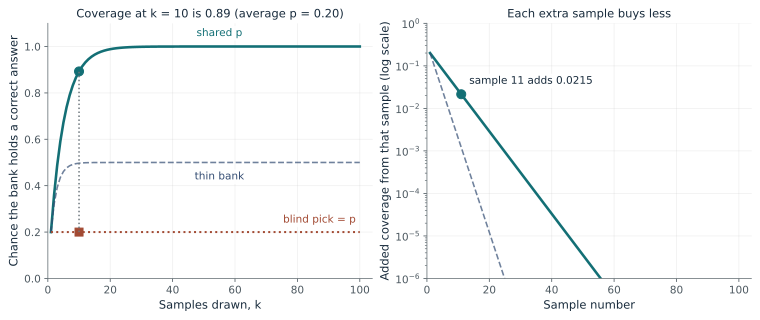

In [8]:
demo_id = 'C16-D01'
demo_controls = {'spread': 'shared', 'p': 0.2, 'k': 10}
demo_result = run_demo(16, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **How the chance is spread over problems** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

Sampling fills the bank, but a blind pick ignores it
Controls: {"spread": "thin", "p": 0.2, "k": 10}
Evidence: constructed teaching example

Calculated quantities:
Coverage Cov(k): 0.4970
Blind selection Sel(k): 0.20
Gap a selector could close: 0.2970
Gain from sample 11: 0.0012
Coverage at 20 samples: 0.5000
Gain from sample 5: 0.0259
Gain from sample 20: 1.2e-05

Worked steps:
1. Half the problems have chance 2p = 0.40 per sample, half have 0.
2. Average chance of one sample: 0.5 x 0.40 + 0.5 x 0 = 0.20 = p.
3. On the half at 0.40: all 10 wrong is 0.60^10 = 0.006047, so coverage there is 0.993953.
4. Cov(10) = 0.5 x 0.993953 + 0.5 x 0 = 0.4970.
5. With every problem at p, Cov(10) = 1 - 0.80^10 = 0.8926.
6. Blind pick: still 0.20. Sample 11 adds 0.5 x 0.40 x 0.60^10 = 0.0012.

Half the problems have chance 2p = 0.40 per sample and half have 0, so the average chance is 0.5 x 0.40 + 0.5 x 0 = 0.20, the same p as before. Cov(10) = 0.5 x (1 - 0.60^10) + 0.5 x 0 = 0.5 x 0.993953 = 0.4970, 

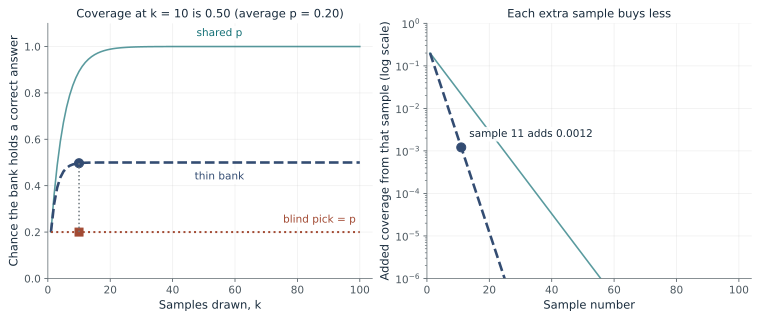

In [9]:
changed_controls = {'spread': 'thin', 'p': 0.2, 'k': 10}
changed_demo = run_demo(16, 'C16-D01', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [10]:
state_rows = []
for controls in demo_states(16, 'C16-D01'):
    state = run_demo(16, 'C16-D01', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "spread": "shared",
      "p": 0.05,
      "k": 10
    },
    "metrics": [
      [
        "Coverage Cov(k)",
        "0.4013"
      ],
      [
        "Blind selection Sel(k)",
        "0.05"
      ],
      [
        "Gap a selector could close",
        "0.3513"
      ],
      [
        "Gain from sample 11",
        "0.0299"
      ],
      [
        "Coverage at 20 samples",
        "0.6415"
      ],
      [
        "Gain from sample 5",
        "0.0407"
      ],
      [
        "Gain from sample 20",
        "0.0189"
      ]
    ]
  },
  {
    "controls": {
      "spread": "shared",
      "p": 0.05,
      "k": 100
    },
    "metrics": [
      [
        "Coverage Cov(k)",
        "0.9941"
      ],
      [
        "Blind selection Sel(k)",
        "0.05"
      ],
      [
        "Gap a selector could close",
        "0.9441"
      ],
      [
        "Gain from sample 101",
        "0.0003"
      ],
      [
        "Coverage at 20 samples",
        "0.64

**Check your understanding:** At p = 0.2 with every problem sharing p, what is the coverage of five samples, and what does a blind pick from them deliver?

[Answer and worked reasoning](../solutions/ch16.md#demonstration-1). [Matching browser demonstration](../readers/16-sample-allocation/reader.html#C16-D01).

<a id="demo-c16-d02"></a>

### Demonstration 2: The selector turns coverage into delivery

How much of the coverage reaches the user under a budget and a deadline, and what changes when the samples share one failure or the limits are tight?

![Equation 16.3](../assets/math/948f3cacbf230e54c9e1.svg)

![Equation 16.1](../assets/math/5e2812ebe7973eccf096.svg)

![Equation 16.2](../assets/math/9376402bf0c75d691016.svg)

**Symbols and units:** p is the chance one sample is correct. Cov(k) is the chance a correct sample is in the bank. The selector success shown is the chance the selector ranks a correct sample first when the bank holds one; the book calls it pi(k), and here it is held constant for banks of two or more. With one sample there is nothing to rank. Sel(k) is the chance the returned answer is correct. Blind selection returns p. Cost of n samples is n times the sample cost plus the selector cost (no selector cost for one sample); time is n times the sample time plus the selector time. If the samples share one failure, a bank that holds a correct sample holds only correct samples, so the selector is certain to pick a correct one and its setting is not used.

Equation (16.3) multiplies two chances: a correct sample must be present, and the selector must find it. A perfect selector (1.0) delivers the whole coverage; a weaker one delivers a fraction. If the samples share one failure, coverage stays at p however many are drawn, and a bank that holds a correct sample holds only correct ones, so the selector adds nothing. The right panel adds the resources: an allocation that is over the budget or the deadline stays visible but cannot be chosen, even when its coverage is the highest, and the gap between coverage and delivery tells which part, the generator or the selector, is holding the result back.

**Use in this chapter:** Report coverage and delivery as separate numbers on the same tasks. If coverage is high and delivery low, work on the selector; if coverage itself is low, no selector can help. Keep infeasible rows in the record, as the companion's probe does, and say when none is feasible instead of exceeding a hard limit.

**Assumptions:** A constant selector success is a constructed simplification. The book stresses that a real selector's success must be measured on banks of the size and kind in use, because it depends on ties, on the number of correct answers and on dependence. The shared-failure state is an extreme case chosen to show the boundary; there the selector setting has no effect. Time is serial and the costs are constructed. The rule that a shared failure makes selection equal coverage is the laboratory's and the workbook's convention; the chapter itself states only that dependence breaks Equation (16.1). The no-feasible state uses a budget of 0.5, defined for this reader.

**Predict before running:** With independent samples and a selector that succeeds 0.5 of the time when a correct sample exists, will five samples beat a blind pick of 0.40?

**Controls you can change:**

- **Case and limits:** `setting` accepts 'default', 'shared', 'transfer', 'none'.
- **Selector success when a correct sample exists:** `selector` accepts 0.5, 0.9, 1.0.

**Source section:** The selector needs its own measured success rate.

**Evidence:** constructed teaching example.

Constructed example: the laboratory's sample-allocation function with the notebook's default (p = 0.4, selector 0.9, counts 1, 2, 3 and 5, limits 6 and 6), changed (one shared failure) and transfer cases (p = 0.7, selector 0.5, costs 2 and 3, limits 3 and 6, counts 1, 2 and 4), and the workbook's question about an allocation set with no feasible row (a budget of 0.5, defined for this reader).

Prediction choices:

1. Five samples beat 0.40
2. Five samples fall below 0.40
3. Exactly 0.40

**Common wrong turn:** The chapter keeps the pairwise chance d, that a selector scores one correct sample above one wrong one, apart from the measured top-rank success pi(k) of a bank. Ties, dependence and the number of correct candidates affect pi(k); d alone does not determine it. Here pi is a setting, which is why each state asks what the delivered number is, not how well the selector compares two answers.

The selector turns coverage into delivery
Controls: {"setting": "default", "selector": 0.9}
Evidence: constructed teaching example

Calculated quantities:
Feasible allocations: n = 1, n = 2, n = 3, n = 5
Chosen allocation: n = 5
Coverage of the chosen allocation: 0.9222
Selected success of the chosen allocation: 0.8300
Blind selection: 0.40
Coverage minus delivery at n = 5: 0.0922

Worked steps:
1. Coverage: Cov(5) = 1 - (1 - 0.40)^5 = 0.92224.
2. Delivery: Sel(5) = 0.92224 x 0.90 = 0.8300.
3. n = 5: cost 5 x 1 + 1 = 6, time 5 x 1 + 1 = 6; budget 6, deadline 6 s.
4. n = 1: cost 1 x 1 = 1, time 1 x 1 = 1 (no selector): feasible, Sel = 0.4000.
5. n = 2: cost 2 x 1 + 1 = 3, time 2 x 1 + 1 = 3: feasible, Sel = 0.5760.
6. n = 3: cost 3 x 1 + 1 = 4, time 3 x 1 + 1 = 4: feasible, Sel = 0.7056.
7. Rule: highest selected success among the feasible rows; ties go to lower cost.

Cov(5) = 1 - (1 - 0.40)^5 = 1 - 0.07776 = 0.92224. Sel(5) = 0.92224 x 0.90 + (1 - 0.92224) x 0 = 0.8300; n = 5: cost 5 

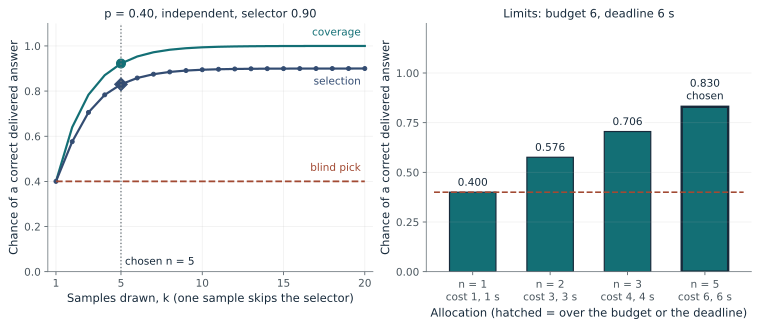

In [11]:
demo_id = 'C16-D02'
demo_controls = {'setting': 'default', 'selector': 0.9}
demo_result = run_demo(16, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Case and limits** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

The selector turns coverage into delivery
Controls: {"setting": "shared", "selector": 0.9}
Evidence: constructed teaching example

Calculated quantities:
Feasible allocations: n = 1, n = 2, n = 3, n = 5
Chosen allocation: n = 1
Coverage of the chosen allocation: 0.4000
Selected success of the chosen allocation: 0.4000
Blind selection: 0.40
Coverage minus delivery at n = 5: 0.0000

Worked steps:
1. One sample skips the selector: Sel(1) = p = 0.40.
2. n = 1: cost 1 x 1 = 1, time 1 x 1 = 1 (no selector); budget 6, deadline 6 s.
3. n = 2: cost 2 x 1 + 1 = 3, time 2 x 1 + 1 = 3: feasible, Sel = 0.4000.
4. n = 3: cost 3 x 1 + 1 = 4, time 3 x 1 + 1 = 4: feasible, Sel = 0.4000.
5. n = 5: cost 5 x 1 + 1 = 6, time 5 x 1 + 1 = 6: feasible, Sel = 0.4000.
6. Rule: highest selected success among the feasible rows; ties go to lower cost.

One sample skips the selector, so Sel(1) = p = 0.40; n = 1: cost 1 x 1 = 1, time 1 x 1 = 1 (no selector), inside the budget 6 and the deadline 6 s. Other rows: n = 

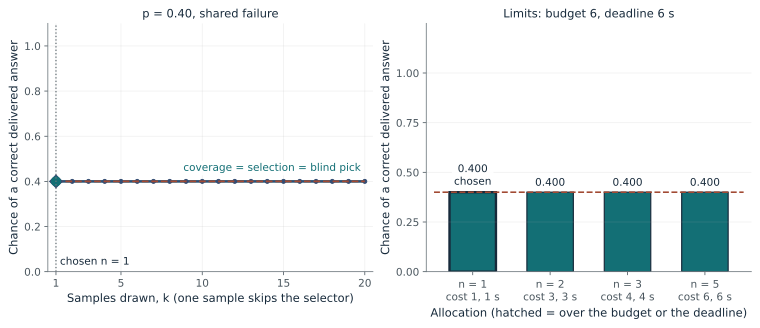

In [12]:
changed_controls = {'setting': 'shared', 'selector': 0.9}
changed_demo = run_demo(16, 'C16-D02', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [13]:
state_rows = []
for controls in demo_states(16, 'C16-D02'):
    state = run_demo(16, 'C16-D02', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "setting": "default",
      "selector": 0.5
    },
    "metrics": [
      [
        "Feasible allocations",
        "n = 1, n = 2, n = 3, n = 5"
      ],
      [
        "Chosen allocation",
        "n = 5"
      ],
      [
        "Coverage of the chosen allocation",
        "0.9222"
      ],
      [
        "Selected success of the chosen allocation",
        "0.4611"
      ],
      [
        "Blind selection",
        "0.40"
      ],
      [
        "Coverage minus delivery at n = 5",
        "0.4611"
      ]
    ]
  },
  {
    "controls": {
      "setting": "default",
      "selector": 0.9
    },
    "metrics": [
      [
        "Feasible allocations",
        "n = 1, n = 2, n = 3, n = 5"
      ],
      [
        "Chosen allocation",
        "n = 5"
      ],
      [
        "Coverage of the chosen allocation",
        "0.9222"
      ],
      [
        "Selected success of the chosen allocation",
        "0.8300"
      ],
      [
        "Blind selectio

**Check your understanding:** With independent samples, p = 0.4 and selector success 0.75, what is Sel(3)?

[Answer and worked reasoning](../solutions/ch16.md#demonstration-2). [Matching browser demonstration](../readers/16-sample-allocation/reader.html#C16-D02).

<a id="demo-c16-d03"></a>

### Demonstration 3: Length, volume or a selector: spending sixty units

With 60 units of compute, does it matter more to think longer, to sample more, or to pay for a selector?

![Equation 16.3](../assets/math/948f3cacbf230e54c9e1.svg)

![Equation 16.2](../assets/math/9376402bf0c75d691016.svg)

![Equation 16.1](../assets/math/5e2812ebe7973eccf096.svg)

![Equation 16.4](../assets/math/54144b0cebaad6ba0716.svg)

**Symbols and units:** One unit is one short generation. A long reasoning chain costs 4 units and raises the chance one sample is correct from 0.20 to the chosen value. Checking a sample with the selector costs a quarter of a unit. Cov is coverage, Sel the chance the returned answer is correct, and the selector success pi is the chance it ranks a correct sample first. Bars show Sel; diamonds show Cov.

Without a selector, Equation (16.2) says delivery is just p, so fifteen long samples deliver the long-chain p and sixty short samples deliver 0.20, however many samples were paid for. With a selector, Equation (16.3) multiplies a coverage near one by the selector success, so the selector's quality sets the result. Once coverage is near one, Equation (16.4) says another sample adds almost nothing, which is why, at the chapter's 0.35, the nine units left over by allocation 4 are not best spent on more samples.

**Use in this chapter:** When splitting a fixed budget, price every lever in one unit and compute delivery for each combination. Do the arithmetic before arguing about whether longer reasoning or more samples is the better lever.

**Assumptions:** The costs, the two p values and the selector successes are constructed; the book states them to show the ordering, not as results for any real system. Selector success is held constant across bank sizes here. A selector that ranks correct answers below wrong ones, as in the 0.15 state, can do worse than not selecting.

**Predict before running:** Using the book's selector values, which allocation comes out highest?

**Controls you can change:**

- **Selector success (allocations 3 and 4):** `selector` accepts 'book', 'strong', 'weak', 'worse'.
- **Chance one long-reasoning sample is correct:** `long_p` accepts 0.35, 0.25.

**Source section:** Three levers, one budget.

**Evidence:** constructed teaching example.

Constructed example: the chapter's sixty-unit construction (Figure 16.3), including its stipulated selector values 0.73 and 0.785, with the other selector values and the second long-chain p defined for this reader.

Prediction choices:

1. 1. All on length
2. 2. All on volume
3. 3. Volume with a selector
4. 4. Length with a selector

**Common wrong turn:** The chapter says the selection argument is not saying that a system without a good selector should think less. Longer reasoning raises p directly, which raises delivery under blind selection too (Sel = p). Compare allocation 1 (0.35) with allocation 2 (0.20): length helped with no selector at all. What blind selection denies is that drawing more samples helps.

Length, volume or a selector: spending sixty units
Controls: {"selector": "book", "long_p": 0.35}
Evidence: constructed teaching example

Calculated quantities:
All on length: 0.350
All on volume: 0.200
Volume + selector: 0.730
Length + selector: 0.781
Best allocation: Length + selector

Worked steps:
1. Allocation 1: 15 long samples, blind: Sel = p = 0.35.
2. Allocation 2: 60 short samples, blind: Sel = p = 0.20.
3. Allocation 3: Cov(48) = 1 - 0.8^48 = 0.99998; Sel = 0.99998 x 0.73 = 0.730.
4. Allocation 4: Cov(12) = 1 - 0.65^12 = 0.9943; Sel = 0.9943 x 0.785 = 0.781.
5. Units: allocation 4 uses 12 x 4 + 12 x 0.25 = 51 of 60, leaving 9.
6. A thirteenth long sample adds 0.35 x 0.65^12 = 0.0020 (Equation 16.4).
7. Highest delivered: Length + selector.

Allocation 1: blind, so Sel = p = 0.35. Allocation 2: Sel = p = 0.20. Allocation 3: Cov(48) = 1 - 0.8^48 = 0.99998, so Sel = 0.99998 x 0.73 = 0.730. Allocation 4: Cov(12) = 1 - 0.65^12 = 0.9943, so Sel = 0.9943 x 0.785 = 0.781. Spending: 

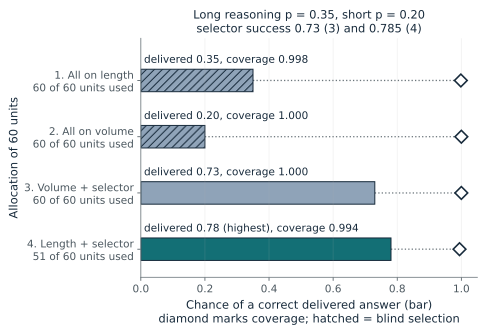

In [14]:
demo_id = 'C16-D03'
demo_controls = {'selector': 'book', 'long_p': 0.35}
demo_result = run_demo(16, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Selector success (allocations 3 and 4)** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

Length, volume or a selector: spending sixty units
Controls: {"selector": "strong", "long_p": 0.35}
Evidence: constructed teaching example

Calculated quantities:
All on length: 0.350
All on volume: 0.200
Volume + selector: 0.950
Length + selector: 0.945
Best allocation: Volume + selector

Worked steps:
1. Allocation 1: 15 long samples, blind: Sel = p = 0.35.
2. Allocation 2: 60 short samples, blind: Sel = p = 0.20.
3. Allocation 3: Cov(48) = 1 - 0.8^48 = 0.99998; Sel = 0.99998 x 0.95 = 0.950.
4. Allocation 4: Cov(12) = 1 - 0.65^12 = 0.9943; Sel = 0.9943 x 0.95 = 0.945.
5. Units: allocation 4 uses 12 x 4 + 12 x 0.25 = 51 of 60, leaving 9.
6. A thirteenth long sample adds 0.35 x 0.65^12 = 0.0020 (Equation 16.4).
7. Highest delivered: Volume + selector.

Allocation 1: blind, so Sel = p = 0.35. Allocation 2: Sel = p = 0.20. Allocation 3: Cov(48) = 1 - 0.8^48 = 0.99998, so Sel = 0.99998 x 0.95 = 0.950. Allocation 4: Cov(12) = 1 - 0.65^12 = 0.9943, so Sel = 0.9943 x 0.95 = 0.945. Spending: 

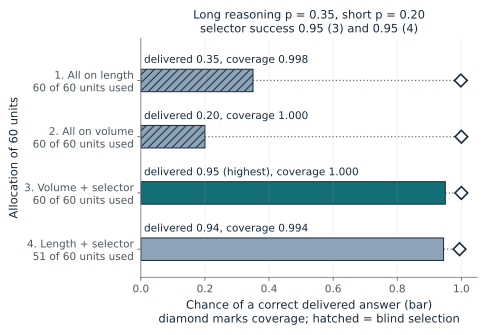

In [15]:
changed_controls = {'selector': 'strong', 'long_p': 0.35}
changed_demo = run_demo(16, 'C16-D03', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [16]:
state_rows = []
for controls in demo_states(16, 'C16-D03'):
    state = run_demo(16, 'C16-D03', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "selector": "book",
      "long_p": 0.35
    },
    "metrics": [
      [
        "All on length",
        "0.350"
      ],
      [
        "All on volume",
        "0.200"
      ],
      [
        "Volume + selector",
        "0.730"
      ],
      [
        "Length + selector",
        "0.781"
      ],
      [
        "Best allocation",
        "Length + selector"
      ]
    ]
  },
  {
    "controls": {
      "selector": "book",
      "long_p": 0.25
    },
    "metrics": [
      [
        "All on length",
        "0.250"
      ],
      [
        "All on volume",
        "0.200"
      ],
      [
        "Volume + selector",
        "0.730"
      ],
      [
        "Length + selector",
        "0.760"
      ],
      [
        "Best allocation",
        "Length + selector"
      ]
    ]
  },
  {
    "controls": {
      "selector": "strong",
      "long_p": 0.35
    },
    "metrics": [
      [
        "All on length",
        "0.350"
      ],
      [
       

**Check your understanding:** Short samples cost 1 unit and long ones 4. With 20 short samples verified at 0.25 each, how many units are used, and what is Sel if pi = 0.6 and p = 0.2?

[Answer and worked reasoning](../solutions/ch16.md#demonstration-3). [Matching browser demonstration](../readers/16-sample-allocation/reader.html#C16-D03).

<a id="demo-c16-d04"></a>

### Demonstration 4: What a completed task costs, and who is allowed to be slow

Which procedure is cheapest per authorized success once a completion floor and a deadline rule some out, and what does the ratio do when nothing succeeds?

![Equation 16.5](../assets/math/65a73d2e35e3d927a4fe.svg)

**Symbols and units:** N is the number of attempted tasks (100 here). The cost of run i, written c with subscript i in the equation, counts failed attempts too. The indicator in the denominator is 1 when run i ended in an authorized, confirmed completion and 0 otherwise, so the denominator counts those runs. Cost per success is total cost divided by that count. Completion rate is the share of attempts that succeed; response time is seconds to answer. A failed task is also given a loss of 20 in one metric. The Pareto frontier keeps the procedures that no other procedure beats on completion, cost and time at once.

Equation (16.5) divides everything spent by the number of real successes, so cheap procedures that fail often can still look cheap per success while missing the owner's requirements. A deadline and a completion floor are separate constraints and remove procedures before any ratio is compared. If none remains, the ratio does not choose for the owner. The ratio also needs a denominator: with two observed attempts and no success, Equation (16.5) has no value, and a printable replacement would change the metric.

**Use in this chapter:** When reporting an efficiency ratio, count every attempt's cost, count only runs that met the declared completion contract, and state the constraints the ratio does not capture. Report a zero denominator as undefined, with the attempted-task count and the total cost.

**Assumptions:** Three constructed procedures with known costs, completion rates and response times. Real rates must be estimated on matching tasks, and a ratio from a small sample is a different object from the underlying rate. The two observed attempts describe a sample, not the population ratios. The Pareto statement is about the three procedures as stated; it does not pick one for a particular deadline or authority contract.

**Predict before running:** With a 3 second deadline and a completion floor of 0.75, which procedure is the only feasible one?

**Controls you can change:**

- **Deadline (seconds, declared rates only):** `deadline` accepts 3, 10.
- **Minimum completion rate required (declared rates only):** `required` accepts 0.5, 0.75, 0.82.
- **What the ratio is computed from:** `evidence` accepts 'declared', 'observed'.

**Source section:** What the budget actually buys.

**Evidence:** constructed teaching example.

Constructed example: the chapter's three procedures (costs 1, 1.5, 2; completion 60, 80, 85 percent; response 1, 2, 5 seconds; failure loss 20) and workbench problem E.4 (two attempts costing 2 and 3, neither successful), with the deadline and completion floor varied. The costs and completion rates come from the section named above; the response times, deadlines and the loss of 20 per failure come from the section "Waiting changes the allocation".

Prediction choices:

1. A
2. B
3. C
4. None is feasible

**Common wrong turn:** The chapter notes that A has the lowest cost per success and the lowest completion rate, and that the ratio alone cannot tell an owner who requires at least 75 percent completion which procedure to use: under that requirement, A is inadmissible. Among the three declared procedures the lowest ratio is always A, even when A is not feasible.

What a completed task costs, and who is allowed to be slow
Controls: {"deadline": 10, "required": 0.75, "evidence": "declared"}
Evidence: constructed teaching example

Calculated quantities:
Cost per success A: 1.67
Cost per success B: 1.88
Cost per success C: 2.35
Feasible procedures: B, C
Cheapest per success overall: A
Cheapest per success among feasible: B
Lowest cost plus failure loss (20 per failure): C
Procedures on the Pareto frontier: A, B, C

Worked steps:
1. A: total cost 100 x 1 = 100, successes 100 x 0.60 = 60, so 100 / 60 = 1.6667.
2. B: total cost 100 x 1.5 = 150, successes 100 x 0.80 = 80, so 150 / 80 = 1.8750.
3. C: total cost 100 x 2 = 200, successes 100 x 0.85 = 85, so 200 / 85 = 2.3529.
4. Feasible needs completion at least 0.75 and time at most 10 s: B, C.
5. Cheapest per success among the feasible: B (1.8750).
6. With a loss of 20 per failure: A 9.0, B 5.5, C 5.0; lowest among the feasible is C.

Over 100 attempts, Equation (16.5) gives A: 100 x 1 / (100 x 0.60) =

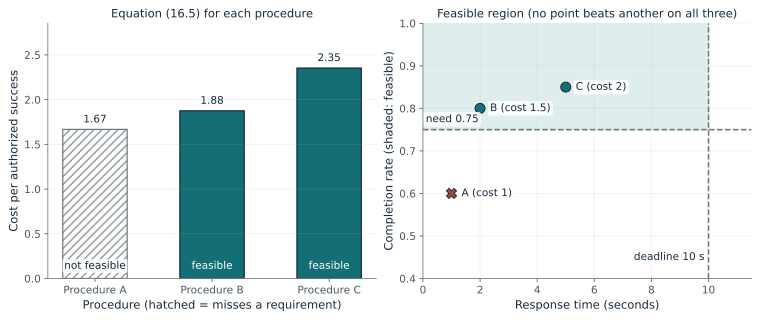

In [17]:
demo_id = 'C16-D04'
demo_controls = {'deadline': 10, 'required': 0.75, 'evidence': 'declared'}
demo_result = run_demo(16, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Deadline (seconds, declared rates only)** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

What a completed task costs, and who is allowed to be slow
Controls: {"deadline": 3, "required": 0.75, "evidence": "declared"}
Evidence: constructed teaching example

Calculated quantities:
Cost per success A: 1.67
Cost per success B: 1.88
Cost per success C: 2.35
Feasible procedures: B
Cheapest per success overall: A
Cheapest per success among feasible: B
Lowest cost plus failure loss (20 per failure): B
Procedures on the Pareto frontier: A, B, C

Worked steps:
1. A: total cost 100 x 1 = 100, successes 100 x 0.60 = 60, so 100 / 60 = 1.6667.
2. B: total cost 100 x 1.5 = 150, successes 100 x 0.80 = 80, so 150 / 80 = 1.8750.
3. C: total cost 100 x 2 = 200, successes 100 x 0.85 = 85, so 200 / 85 = 2.3529.
4. Feasible needs completion at least 0.75 and time at most 3 s: B.
5. Cheapest per success among the feasible: B (1.8750).
6. With a loss of 20 per failure: A 9.0, B 5.5, C 5.0; lowest among the feasible is B.

Over 100 attempts, Equation (16.5) gives A: 100 x 1 / (100 x 0.60) = 100 / 6

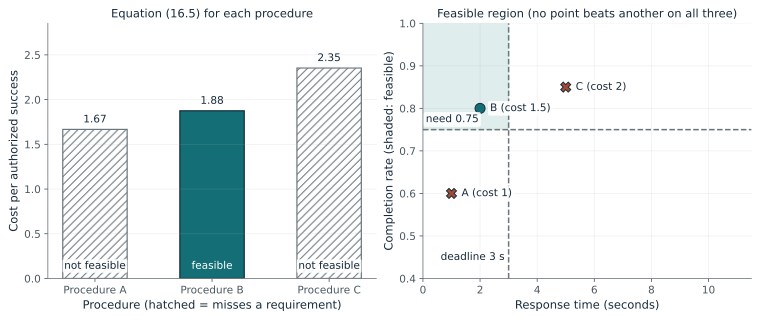

In [18]:
changed_controls = {'deadline': 3, 'required': 0.75, 'evidence': 'declared'}
changed_demo = run_demo(16, 'C16-D04', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [19]:
state_rows = []
for controls in demo_states(16, 'C16-D04'):
    state = run_demo(16, 'C16-D04', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "deadline": 3,
      "required": 0.5,
      "evidence": "declared"
    },
    "metrics": [
      [
        "Cost per success A",
        "1.67"
      ],
      [
        "Cost per success B",
        "1.88"
      ],
      [
        "Cost per success C",
        "2.35"
      ],
      [
        "Feasible procedures",
        "A, B"
      ],
      [
        "Cheapest per success overall",
        "A"
      ],
      [
        "Cheapest per success among feasible",
        "A"
      ],
      [
        "Lowest cost plus failure loss (20 per failure)",
        "B"
      ],
      [
        "Procedures on the Pareto frontier",
        "A, B, C"
      ]
    ]
  },
  {
    "controls": {
      "deadline": 3,
      "required": 0.5,
      "evidence": "observed"
    },
    "metrics": [
      [
        "Attempts",
        "2"
      ],
      [
        "Total cost",
        "5.0"
      ],
      [
        "Authorized confirmed completions",
        "0"
      ],
      [
      

**Check your understanding:** A procedure costs 3 per attempt and completes 0.5 of 100 attempts. What is its cost per success?

[Answer and worked reasoning](../solutions/ch16.md#demonstration-4). [Matching browser demonstration](../readers/16-sample-allocation/reader.html#C16-D04).

## Questions

1. Compute default n=5 coverage and selection.

2. Why prefer n1 under shared error?

3. What if no allocation is feasible?

Answers: [separate solutions](../solutions/ch16.md). Try the calculation before opening them.

## Summary

Sampling, selection, and feasible completion are separate layers. Independent coverage can rise with candidate count, while shared failures prevent that gain and selector mistakes consume it. Cost and deadlines filter allocations before choice. The default uses five samples, the shared-error case prefers one, and the transfer checks overhead limits. The result is conditional on declared probabilities and serial resource accounting, without turning repeated agreement into correctness evidence.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-16-sample-allocation`](../skills/maa-16-sample-allocation/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 16.1

![Equation 16.1](../assets/math/5e2812ebe7973eccf096.svg)

Equation (16.1) gives the chance that at least one of `k` samples is correct.

One minus the chance that every single sample is wrong.

LaTeX source, preserved for inspection:

```latex
\operatorname{Cov}(k) \;=\; 1 - (1-p)^{k}.
\tag{16.1}
```

### Equation 16.2

![Equation 16.2](../assets/math/9376402bf0c75d691016.svg)

Equation (16.2) gives the chance the returned sample is correct when the selector is blind.

The expected fraction of correct samples among the `k` drawn is `p`, whatever `k` is.

LaTeX source, preserved for inspection:

```latex
\operatorname{Sel}(k) \;=\; \mathrm{E}\!\left[\frac{m}{k}\right] \;=\; p .
\tag{16.2}
```

### Equation 16.3

![Equation 16.3](../assets/math/948f3cacbf230e54c9e1.svg)

Equation (16.3) splits the returned answer's correctness into whether a correct sample was present and whether the selector found it.

Multiply the chance that a correct sample exists among the `k` by the chance the selector ranks one of them top.

LaTeX source, preserved for inspection:

```latex
\operatorname{Sel}(k) \;=\; \operatorname{Cov}(k)\cdot \pi(k) \;+\; \big(1-\operatorname{Cov}(k)\big)\cdot 0 ,
\tag{16.3}
```

### Equation 16.4

![Equation 16.4](../assets/math/54144b0cebaad6ba0716.svg)

Equation (16.4) gives the value of drawing one more sample, before any selector is applied.

The gain from sample number `k` plus one is the chance it is correct times the chance all the previous ones were not.

LaTeX source, preserved for inspection:

```latex
\operatorname{Cov}(k+1) - \operatorname{Cov}(k) \;=\; p\,(1-p)^{k}.
\tag{16.4}
```

### Equation 16.5

![Equation 16.5](../assets/math/65a73d2e35e3d927a4fe.svg)

Equation (16.5) allocates all observed attempt costs across the observed authorized completions.

Add every run's cost, then divide by the number of runs that actually satisfied the declared completion contract.

LaTeX source, preserved for inspection:

```latex
\widehat c_{\mathrm{success}}
=
\frac{\sum_{i=1}^{N}c_i}
{\sum_{i=1}^{N}\mathbf 1\{\text{authorized confirmed completion in run }i\}}.
\tag{16.5}
```